# 10 — Decision Policy Lab · Closed Loop
## `bd_replica_crm` — score → recomendación → acción → outcome → medición → aprendizaje

Este notebook cierra el primer ciclo operativo completo de Decision Intelligence para `priorizacion_leads`.

**Contrato real del repositorio:**

```text
features.lead_evidence
        ↓
decision_intelligence.lead_scores
        ↓
sync_recommendations()
        ↓
decision_intelligence.recommendations
        ↓
register_action()           ← humano / simulación controlada
        ↓
decision_intelligence.actions
        ↓
refresh_outcomes()
        ↓
decision_intelligence.outcomes
        ↓
v_lead_action_outcome
        ↓
v_lead_action_outcome_performance
        ↓
aprendizaje / siguiente policy
```

### Principio de seguridad

Por defecto el notebook corre en **DRY RUN**.

No contacta a ningún lead ni ejecuta acciones comerciales externas.  
La acción puede registrarse en el DW solamente cuando se activa explícitamente `WRITE_MODE=True`.

La semántica actual es **PROPENSITY_NOT_CAUSAL_UPLIFT**: el score prioriza, pero no demuestra que contactar cause la conversión.


In [1]:
from __future__ import annotations

import sys, json, uuid
from pathlib import Path
from datetime import datetime, timezone
from decimal import Decimal

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd=Path.cwd().resolve()
PROJECT_ROOT=cwd if (cwd/"pyproject.toml").exists() else cwd.parent
if not (PROJECT_ROOT/"pyproject.toml").exists():
    raise RuntimeError("Ejecuta este notebook dentro de bd_replica_crm.")

SRC=PROJECT_ROOT/"src"
if str(SRC) not in sys.path:
    sys.path.insert(0,str(SRC))

from replica_cygnus.settings import load_settings
from replica_cygnus.connections import connect_postgres
from replica_cygnus.lead_scoring.config import load_lead_scoring_config
from replica_cygnus.lead_scoring.feedback import (
    DECISION_SYSTEM,
    recommended_action_for_band,
    sync_recommendations,
    register_action,
    refresh_outcomes,
    measurement_summary,
)

settings=load_settings(PROJECT_ROOT)
conn=connect_postgres(settings)

CONFIG_PATH=PROJECT_ROOT/"config"/"lead_scoring.yml"
if not CONFIG_PATH.exists():
    CONFIG_PATH=PROJECT_ROOT/"config"/"lead_scoring.example.yml"
cfg=load_lead_scoring_config(CONFIG_PATH)

pd.set_option("display.max_columns",180)
pd.set_option("display.max_rows",180)
pd.set_option("display.width",260)

def sql_df(sql,params=None):
    with conn.cursor() as cur:
        cur.execute(sql,params or ())
        names=[d.name for d in cur.description]
        return pd.DataFrame(cur.fetchall(),columns=names)

def exists(schema,name):
    q=sql_df("""
    SELECT EXISTS(
      SELECT 1 FROM information_schema.tables WHERE table_schema=%s AND table_name=%s
      UNION ALL
      SELECT 1 FROM information_schema.views WHERE table_schema=%s AND table_name=%s
    ) ok
    """,(schema,name,schema,name))
    return bool(q.iloc[0]["ok"])

def columns_of(schema,name):
    return sql_df("""
    SELECT ordinal_position,column_name,data_type,is_nullable
    FROM information_schema.columns
    WHERE table_schema=%s AND table_name=%s
    ORDER BY ordinal_position
    """,(schema,name))

print("DB:",settings.postgres.database)
print("Decision system:",DECISION_SYSTEM)
print("Config:",CONFIG_PATH)
print("Inicio:",datetime.now().astimezone().isoformat(timespec="seconds"))


DB: medallio_dw
Decision system: priorizacion_leads
Config: C:\AI\replica_redshift_local\replica_redshift_local\config\lead_scoring.yml
Inicio: 2026-09-07T17:40:50-05:00


## 1. Control panel — empieza aquí


In [2]:
# ==========================================================
# CONTROL PANEL
# ==========================================================

WRITE_MODE=False
# False = análisis/simulación solamente.
# True  = permite materializar recomendaciones y registrar
#         UNA acción humana/simulada elegida explícitamente.

SYNC_RECOMMENDATIONS=False
REFRESH_MATURED_OUTCOMES=False
REGISTER_ONE_ACTION=False

# Política operativa propuesta.
POLICY_ID="lead_priority_v1"

ALLOWED_BANDS=["A","B"]
MIN_PRIORITY_SCORE=70.0
DAILY_CAPACITY=100

SLA_BY_BAND={
    "A":15,
    "B":60,
    "C":1440,
    "D":1440,
}

# Solo se usa si REGISTER_ONE_ACTION=True.
SELECTED_RECOMMENDATION_ID=None
ACTION_OWNER="LAB_SIMULATION"
ACTION_COST=0.0
ACTION_NOTES="Registro controlado desde 10_decision_policy_lab"

print({
    "WRITE_MODE":WRITE_MODE,
    "SYNC_RECOMMENDATIONS":SYNC_RECOMMENDATIONS,
    "REFRESH_MATURED_OUTCOMES":REFRESH_MATURED_OUTCOMES,
    "REGISTER_ONE_ACTION":REGISTER_ONE_ACTION,
    "POLICY_ID":POLICY_ID,
    "ALLOWED_BANDS":ALLOWED_BANDS,
    "MIN_PRIORITY_SCORE":MIN_PRIORITY_SCORE,
    "DAILY_CAPACITY":DAILY_CAPACITY,
})


{'WRITE_MODE': False, 'SYNC_RECOMMENDATIONS': False, 'REFRESH_MATURED_OUTCOMES': False, 'REGISTER_ONE_ACTION': False, 'POLICY_ID': 'lead_priority_v1', 'ALLOWED_BANDS': ['A', 'B'], 'MIN_PRIORITY_SCORE': 70.0, 'DAILY_CAPACITY': 100}


## 2. Gate 0 — contratos reales del DW


In [3]:
required=[
("features","lead_evidence"),
("model_control","model_runs"),
("model_control","model_aliases"),
("decision_intelligence","lead_scores"),
("decision_intelligence","recommendations"),
("decision_intelligence","actions"),
("decision_intelligence","outcomes"),
("decision_intelligence","v_lead_priority_current"),
("decision_intelligence","v_lead_action_outcome"),
("decision_intelligence","v_lead_action_outcome_performance"),
]

contract=pd.DataFrame(
    [(s,o,exists(s,o)) for s,o in required],
    columns=["schema","object","exists"]
)
display(contract)

for s,o in required:
    if exists(s,o):
        print(f"\n{s}.{o}")
        display(columns_of(s,o))


,schema,object,exists
0,features,lead_evidence,True
1,model_control,model_runs,True
2,model_control,model_aliases,True
3,decision_intelligence,lead_scores,True
4,decision_intelligence,recommendations,True
5,decision_intelligence,actions,True
6,decision_intelligence,outcomes,True
7,decision_intelligence,v_lead_priority_current,True
8,decision_intelligence,v_lead_action_outcome,True
9,decision_intelligence,v_lead_action_outcome_performance,True



features.lead_evidence


,ordinal_position,column_name,data_type,is_nullable
0,1,evidence_key,text,NO
1,2,lead_id,text,NO
2,3,decision_at,timestamp with time zone,NO
3,4,captured_at,timestamp with time zone,NO
4,5,evidence_source,text,NO
5,6,documento_cliente,text,NO
6,7,codigo_proyecto,text,NO
7,8,asesor,text,YES
8,9,canal,text,YES
9,10,medio,text,YES



model_control.model_runs


,ordinal_position,column_name,data_type,is_nullable
0,1,model_run_id,uuid,NO
1,2,decision_system,text,NO
2,3,model_name,text,NO
3,4,model_version,text,NO
4,5,trained_at,timestamp with time zone,NO
5,6,training_window_from,timestamp with time zone,YES
6,7,training_window_to,timestamp with time zone,YES
7,8,target,text,YES
8,9,feature_list,jsonb,NO
9,10,metrics,jsonb,NO


...

,ordinal_position,column_name,data_type,is_nullable
0,1,evidence_key,text,YES
1,2,lead_id,text,YES
2,3,documento_cliente,text,YES
3,4,codigo_proyecto,text,YES
4,5,asesor,text,YES
5,6,canal,text,YES
6,7,medio,text,YES
7,8,decision_at,timestamp with time zone,YES
8,9,decision_date,date,YES
9,10,scored_at,timestamp with time zone,YES



decision_intelligence.v_lead_action_outcome


,ordinal_position,column_name,data_type,is_nullable
0,1,recommendation_id,uuid,YES
1,2,evidence_key,text,YES
2,3,lead_id,text,YES
3,4,decision_date,date,YES
4,5,scored_at,timestamp with time zone,YES
5,6,model_run_id,uuid,YES
6,7,priority_band,text,YES
7,8,priority_score,double precision,YES
8,9,p_minuta_60d,double precision,YES
9,10,recommended_action,text,YES



decision_intelligence.v_lead_action_outcome_performance


,ordinal_position,column_name,data_type,is_nullable
0,1,decision_date,date,YES
1,2,priority_band,text,YES
2,3,action_status,text,YES
3,4,action_taken,text,YES
4,5,recommendations,bigint,YES
5,6,actions_recorded,bigint,YES
6,7,sep_matured,bigint,YES
7,8,sep_rate,numeric,YES
8,9,minuta_matured,bigint,YES
9,10,minuta_rate,numeric,YES


## 3. Decision Contract


In [4]:
if exists("decision_intelligence","decision_contracts"):
    decision_contract=sql_df("""
    SELECT *
    FROM decision_intelligence.decision_contracts
    WHERE decision_system=%s
    """,(DECISION_SYSTEM,))
    display(decision_contract)
else:
    decision_contract=pd.DataFrame()
    print("PENDING: decision_contracts no existe.")


,decision_system,objective,decision_unit,decision_owner,target,prediction_horizon_days,causal_estimand,primary_value_metric,feedback_outcome,contract_json,is_active,created_at,updated_at
0,priorizacion_leads,Priorizar atención comercial con evidencia poi...,asignacion de lead (evidence_key),supervisor comercial,minuta_60d,60,"No identificado en v0: propensión, no uplift",tasa de minuta y valor incremental futuro,separacion_14d + minuta_60d,"{'semantics': 'PROPENSITY_NOT_CAUSAL_UPLIFT', ...",True,2026-09-06 20:56:57.550578-05:00,2026-09-06 23:08:47.789763-05:00


## 4. Estado del loop antes de actuar


In [5]:
counts=[]

for s,o in [
    ("features","lead_evidence"),
    ("decision_intelligence","lead_scores"),
    ("decision_intelligence","recommendations"),
    ("decision_intelligence","actions"),
    ("decision_intelligence","outcomes"),
]:
    if exists(s,o):
        n=int(sql_df(f"SELECT COUNT(*) n FROM {s}.{o}").iloc[0]["n"])
        counts.append([f"{s}.{o}",n])

loop_counts_before=pd.DataFrame(counts,columns=["stage","rows"])
display(loop_counts_before)

if exists("model_control","v_lead_model_aliases"):
    print("\nServing/champion:")
    display(sql_df("SELECT * FROM model_control.v_lead_model_aliases"))


,stage,rows
0,features.lead_evidence,206043
1,decision_intelligence.lead_scores,2017
2,decision_intelligence.recommendations,2017
3,decision_intelligence.actions,0
4,decision_intelligence.outcomes,113



Serving/champion:


,decision_system,model_name,alias_name,model_run_id,model_version,trained_at,status,updated_at
0,priorizacion_leads,lead_priority_bundle,serving,81bd3d56-570d-464d-b5c1-08778407ad95,leadscore-20260907T165826Z,2026-09-07 11:58:26.606541-05:00,PROVISIONAL,2026-09-07 11:58:26.955184-05:00


## 5. Universo de prioridad actual


In [6]:
if exists("decision_intelligence","v_lead_priority_current"):
    priority=sql_df("""
    SELECT *
    FROM decision_intelligence.v_lead_priority_current
    ORDER BY priority_rank,priority_score DESC
    """)
else:
    priority=pd.DataFrame()

print("priority rows:",len(priority))
display(priority.head(30))


priority rows: 2017


,evidence_key,lead_id,documento_cliente,codigo_proyecto,asesor,canal,medio,decision_at,decision_date,scored_at,model_version,model_status,is_provisional,p_separacion_14d,p_minuta_60d,priority_score,priority_rank,priority_band,label_status,separacion_14d,minuta_60d
0,15e5ace3a644c9389d32a4b310ac3f0a,222707,44445097,MT,None,None,feria inmobiliaria,2026-09-05 20:33:34.541258-05:00,2026-09-05,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.116937,0.098647,10.870681,1,A,PENDING,NaN,None
1,1059570d5e9d366256ac52c9aabc0e04,222588,auto-509116,MT,None,None,meta,2026-09-05 15:24:15.994052-05:00,2026-09-05,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.190547,0.002018,10.570875,1,A,PENDING,NaN,None
2,ee71f1a5082041be4fe3a307038df01a,222929,auto-366305,MT,None,None,feria inmobiliaria,2026-09-06 19:13:11.958158-05:00,2026-09-06,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.110599,0.097849,10.486133,1,A,PENDING,NaN,None
3,c1e332e2292fa844eb70194e1eff87cc,221590,auto-912627,MT,None,None,referido,2026-08-28 15:23:17.325985-05:00,2026-08-28,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.092676,0.106980,9.911257,1,A,PENDING,NaN,None
4,a07cdab9900f174b2151848a24557eb6,218864,44921496,NP,None,None,referido,2026-09-03 20:44:08.111205-05:00,2026-09-03,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.094941,0.084223,9.011775,1,A,PENDING,NaN,None
5,ae75d43aa52b2c751b02c20dfdbe783c,222084,auto-161309,MT,None,None,referido,2026-09-02 12:27:36.199582-05:00,2026-09-02,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.083742,0.094924,8.877411,1,A,PENDING,NaN,None
6,d49374535febce2b802608d7ddf37881,222246,22994134,NP,None,None,referido,2026-09-03 16:58:01.082567-05:00,2026-09-03,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.079858,0.075361,7.783439,1,A,PENDING,NaN,None
7,a8409942cbed80490b4d45857841433a,221498,auto-690723,CP,None,None,referido,2026-08-27 17:46:26.314175-05:00,2026-08-27,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.046175,0.048819,4.736506,1,A,PENDING,NaN,None
8,8db27b33fbc9d69159ad2a32d1fb142d,221721,auto-550785,MD,None,None,caseta de ventas,2026-08-29 17:12:04.832977-05:00,2026-08-29,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.053166,0.036141,4.550494,1,A,PENDING,NaN,None
9,8f2e092c36a3cd39de763c1a702bf7f3,185687,auto-204168,CP,None,None,referido,2026-08-25 15:34:30.705146-05:00,2026-08-25,2026-09-07 11:58:27.708657-05:00,leadscore-20260907T165826Z,PROVISIONAL,True,0.043446,0.044262,4.381346,1,A,PENDING,NaN,None


## 6. Policy simulator — score → recomendación


In [7]:
if len(priority):
    policy_candidates=priority.copy()

    policy_candidates["eligible_policy"]=(
        policy_candidates["priority_band"].isin(ALLOWED_BANDS)
        & (pd.to_numeric(policy_candidates["priority_score"],errors="coerce")>=MIN_PRIORITY_SCORE)
    )

    eligible=(
        policy_candidates[policy_candidates["eligible_policy"]]
        .sort_values(["priority_rank","priority_score"],ascending=[True,False])
        .head(DAILY_CAPACITY)
        .copy()
    )

    eligible["policy_id"]=POLICY_ID
    eligible["recommended_action"]=eligible["priority_band"].map(recommended_action_for_band)
    eligible["sla_minutes"]=eligible["priority_band"].map(SLA_BY_BAND)

    display(eligible[[
        "evidence_key","lead_id","codigo_proyecto","asesor",
        "priority_band","priority_score","priority_rank",
        "p_separacion_14d","p_minuta_60d",
        "policy_id","recommended_action","sla_minutes"
    ]].head(50))

    print("Universe:",len(priority))
    print("Eligible before capacity:",int(policy_candidates["eligible_policy"].sum()))
    print("Served by policy:",len(eligible))
else:
    eligible=pd.DataFrame()
    print("PENDING: no hay prioridad serving.")


,evidence_key,lead_id,codigo_proyecto,asesor,priority_band,priority_score,priority_rank,p_separacion_14d,p_minuta_60d,policy_id,recommended_action,sla_minutes


Universe: 2017
Eligible before capacity: 0
Served by policy: 0


## 7. Sensibilidad threshold × capacidad


,threshold,eligible,served,unserved,capacity_utilization
0,50,0,0,0,0.0
1,60,0,0,0,0.0
2,70,0,0,0,0.0
3,75,0,0,0,0.0
4,80,0,0,0,0.0
5,85,0,0,0,0.0
6,90,0,0,0,0.0


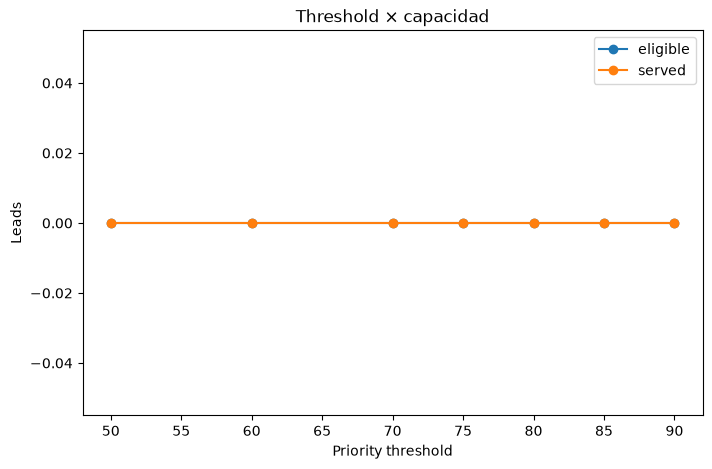

In [8]:
if len(priority):
    rows=[]
    for threshold in [50,60,70,75,80,85,90]:
        n=int((
            priority["priority_band"].isin(ALLOWED_BANDS)
            & (pd.to_numeric(priority["priority_score"],errors="coerce")>=threshold)
        ).sum())

        rows.append({
            "threshold":threshold,
            "eligible":n,
            "served":min(n,DAILY_CAPACITY),
            "unserved":max(n-DAILY_CAPACITY,0),
            "capacity_utilization":min(n,DAILY_CAPACITY)/DAILY_CAPACITY
        })

    policy_sensitivity=pd.DataFrame(rows)
    display(policy_sensitivity)

    plt.figure(figsize=(8,5))
    plt.plot(policy_sensitivity["threshold"],policy_sensitivity["eligible"],marker="o",label="eligible")
    plt.plot(policy_sensitivity["threshold"],policy_sensitivity["served"],marker="o",label="served")
    plt.xlabel("Priority threshold")
    plt.ylabel("Leads")
    plt.title("Threshold × capacidad")
    plt.legend()
    plt.show()


## 8. Gate 1 — ¿podemos materializar recomendaciones?

Para pasar este gate deben existir:

- scores;
- modelo `serving`;
- candidatos;
- contrato DI;
- política con capacidad definida.

El notebook **no entrena ni genera scores**. Si `lead_scores=0`, el bloqueo pertenece al pipeline de scoring.


In [9]:
serving_n=0
if exists("model_control","model_aliases"):
    serving_n=int(sql_df("""
    SELECT COUNT(*) n
    FROM model_control.model_aliases
    WHERE decision_system=%s AND alias_name='serving'
    """,(DECISION_SYSTEM,)).iloc[0]["n"])

score_n=int(loop_counts_before.loc[
    loop_counts_before["stage"].eq("decision_intelligence.lead_scores"),"rows"
].iloc[0]) if (loop_counts_before["stage"]=="decision_intelligence.lead_scores").any() else 0

gates_1=pd.DataFrame([
    ["contract_objects",bool(contract["exists"].all()),f"{contract['exists'].sum()}/{len(contract)}"],
    ["decision_contract",len(decision_contract)>0,f"n={len(decision_contract)}"],
    ["scores",score_n>0,f"n={score_n:,}"],
    ["serving_alias",serving_n>0,f"n={serving_n}"],
    ["policy_candidates",len(eligible)>0,f"n={len(eligible):,}"],
    ["daily_capacity",DAILY_CAPACITY>0,str(DAILY_CAPACITY)],
],columns=["gate","passed","detail"])
gates_1["status"]=np.where(gates_1["passed"],"PASS","BLOCKED")
display(gates_1)


,gate,passed,detail,status
0,contract_objects,True,10/10,PASS
1,decision_contract,True,n=1,PASS
2,scores,True,"n=2,017",PASS
3,serving_alias,True,n=1,PASS
4,policy_candidates,False,n=0,BLOCKED
5,daily_capacity,True,100,PASS


## 9. Materializar recomendaciones — WRITE GATE


In [10]:
synced=0

if SYNC_RECOMMENDATIONS:
    if not WRITE_MODE:
        raise RuntimeError(
            "SYNC_RECOMMENDATIONS=True requiere WRITE_MODE=True. "
            "Revisa primero Gate 1."
        )

    if not bool(gates_1["passed"].all()):
        raise RuntimeError("Gate 1 no está completamente PASS.")

    synced=sync_recommendations(conn)
    print("Recomendaciones sincronizadas:",synced)
else:
    print("DRY RUN: no se escribieron recomendaciones.")


DRY RUN: no se escribieron recomendaciones.


## 10. Recomendaciones actuales


In [11]:
if exists("decision_intelligence","recommendations"):
    recommendations=sql_df("""
    SELECT
      recommendation_id,entity_id AS evidence_key,scored_at,model_run_id,
      predicted_probability,recommended_action,priority_rank,
      context_json->>'lead_id' AS lead_id,
      context_json->>'priority_band' AS priority_band,
      (context_json->>'priority_score')::double precision AS priority_score,
      context_json->>'codigo_proyecto' AS codigo_proyecto,
      context_json->>'asesor' AS asesor
    FROM decision_intelligence.recommendations
    WHERE decision_system=%s
    ORDER BY scored_at DESC,priority_rank
    """,(DECISION_SYSTEM,))
else:
    recommendations=pd.DataFrame()

print("recommendations:",len(recommendations))
display(recommendations.head(50))


recommendations: 2017


,recommendation_id,evidence_key,scored_at,model_run_id,predicted_probability,recommended_action,priority_rank,lead_id,priority_band,priority_score,codigo_proyecto,asesor
0,286f3ba4-2f40-57cf-ae03-6a91f1544cd9,1059570d5e9d366256ac52c9aabc0e04,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.002018,CONTACTAR_PRIORIDAD_ALTA,1,222588,A,10.570875,MT,None
1,7ff33520-a65a-50cd-a902-c3728db575c0,8db27b33fbc9d69159ad2a32d1fb142d,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.036141,CONTACTAR_PRIORIDAD_ALTA,1,221721,A,4.550494,MD,None
2,a7bdda25-022e-5b95-84d3-4405ee91d8eb,a8409942cbed80490b4d45857841433a,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.048819,CONTACTAR_PRIORIDAD_ALTA,1,221498,A,4.736506,CP,None
3,95c72932-5553-5170-8426-9a7673238c05,15e5ace3a644c9389d32a4b310ac3f0a,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.098647,CONTACTAR_PRIORIDAD_ALTA,1,222707,A,10.870681,MT,None
4,caf29cc9-4d4f-51e3-aee5-125366ddf9e1,bb1c97dc77577d7bf61b90ac0ad9c8a6,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.041497,CONTACTAR_PRIORIDAD_ALTA,1,221828,A,3.787836,MT,None
5,4c13b69c-713f-5faa-b176-5fcde422aa5b,ee71f1a5082041be4fe3a307038df01a,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.097849,CONTACTAR_PRIORIDAD_ALTA,1,222929,A,10.486133,MT,None
6,2457c813-c3b8-5c75-a9ff-037abc36c58f,ae75d43aa52b2c751b02c20dfdbe783c,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.094924,CONTACTAR_PRIORIDAD_ALTA,1,222084,A,8.877411,MT,None
7,b8ce6f7b-2c38-59cd-9a7b-10190e9e8f9d,881dafdc1b34e1133f5015d49f165b24,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.031293,CONTACTAR_PRIORIDAD_ALTA,1,221862,A,3.275736,MT,None
8,163449ed-2543-5d16-b5f4-07bd1701e201,f93ee489f489b3e2c548130909e1396e,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.029031,CONTACTAR_PRIORIDAD_ALTA,1,198053,A,3.529712,SL,None
9,955a9212-6c9d-5a00-91f6-a976669e43cc,c1e332e2292fa844eb70194e1eff87cc,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,0.106980,CONTACTAR_PRIORIDAD_ALTA,1,221590,A,9.911257,MT,None


## 11. Gate 2 — seleccionar una recomendación y registrar la acción

El sistema existente está diseñado **human-in-the-loop**: `register_action()` registra lo que una persona hizo; no contacta automáticamente al lead.

Para probar el loop completo de manera controlada:

1. elige un `recommendation_id`;
2. copia el ID al Control Panel;
3. activa `WRITE_MODE=True`;
4. activa `REGISTER_ONE_ACTION=True`;
5. vuelve a ejecutar desde el Control Panel.

La acción registrada será exactamente la acción recomendada, preservando trazabilidad.


In [12]:
selected=pd.DataFrame()

if SELECTED_RECOMMENDATION_ID and len(recommendations):
    selected=recommendations[
        recommendations["recommendation_id"].astype(str).eq(str(SELECTED_RECOMMENDATION_ID))
    ].copy()

display(selected)


""


In [13]:
registered_action_id=None

if REGISTER_ONE_ACTION:
    if not WRITE_MODE:
        raise RuntimeError("REGISTER_ONE_ACTION=True requiere WRITE_MODE=True.")

    if len(selected)!=1:
        raise RuntimeError(
            "Debes seleccionar exactamente un recommendation_id válido."
        )

    rec=selected.iloc[0]

    registered_action_id=register_action(
        conn=conn,
        recommendation_id=str(rec["recommendation_id"]),
        action_taken=str(rec["recommended_action"]),
        action_owner=ACTION_OWNER,
        action_cost=Decimal(str(ACTION_COST)),
        notes=ACTION_NOTES,
    )

    print("action_id:",registered_action_id)
else:
    print("DRY RUN: no se registró acción.")


DRY RUN: no se registró acción.


## 12. Acción → adherence / SLA


In [14]:
if exists("decision_intelligence","v_lead_action_outcome"):
    journey=sql_df("""
    SELECT *
    FROM decision_intelligence.v_lead_action_outcome
    ORDER BY scored_at DESC
    """)
else:
    journey=pd.DataFrame()

print("journeys:",len(journey))
display(journey.head(50))

if len(journey):
    journey["scored_at"]=pd.to_datetime(journey["scored_at"],utc=True,errors="coerce")
    if "action_at" in journey:
        journey["action_at"]=pd.to_datetime(journey["action_at"],utc=True,errors="coerce")
        journey["minutes_to_action"]=(
            journey["action_at"]-journey["scored_at"]
        ).dt.total_seconds()/60

        journey["sla_minutes"]=journey["priority_band"].map(SLA_BY_BAND)
        journey["within_sla"]=np.where(
            journey["action_at"].notna(),
            journey["minutes_to_action"]<=journey["sla_minutes"],
            False
        )

        adherence=pd.DataFrame([{
            "recommendations":len(journey),
            "actions_recorded":journey["action_id"].notna().sum(),
            "action_adoption_rate":journey["action_id"].notna().mean(),
            "followed_recommendation_rate":journey["followed_recommendation"].dropna().mean(),
            "within_sla_rate":journey.loc[journey["action_id"].notna(),"within_sla"].mean(),
            "median_minutes_to_action":journey.loc[journey["action_id"].notna(),"minutes_to_action"].median(),
        }])
        display(adherence)


journeys: 2017


,recommendation_id,evidence_key,lead_id,decision_date,scored_at,model_run_id,priority_band,priority_score,p_minuta_60d,recommended_action,action_id,action_taken,action_owner,action_at,action_cost,action_status,followed_recommendation,separacion_14d,separacion_observed_at,minuta_60d,minuta_observed_at
0,efeacbc5-27d9-5b90-87f0-ece7729aa3b0,000335e373fb80876e81c08adef6e7b4,222112,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,C,0.018319,0.000163,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
1,de5399d6-67f6-5ab7-bae8-4b87dd9d8688,00117958841ca3b4333f84275a421cc3,221162,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,A,2.358566,0.022488,CONTACTAR_PRIORIDAD_ALTA,None,None,None,None,None,NOT_RECORDED,None,0.0000,2026-09-07 16:48:06.358714-05:00,None,None
2,0f4810b0-b20c-5003-a3b3-8f08d719478d,003f107e8044c8d26ec60900758d7b6c,221276,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,C,0.017572,0.000160,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
3,115a3f68-6235-5487-bfa4-894fcdbabf4c,00459f406d8d9264a166e16add87060e,222300,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,B,0.038245,0.000318,CONTACTAR,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
4,82433a1a-5173-5519-a771-27dd3e40b07a,0061fbeb048a694330fcbef742d4e4e8,222849,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,B,0.742540,0.007445,CONTACTAR,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
5,80a74a9e-f06a-519f-bf17-9ff11eabe6e7,00ce8a86b85edb1dca1358e628fb3448,222132,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,C,0.018287,0.000168,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
6,eb8ad2d7-1be7-52e9-9b86-0a463c65ee2c,00e27af7fee382d0d95c0f13488a10c0,200401,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,C,0.014978,0.000137,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
7,2893bf3e-a75d-5130-9c21-812cc262d7c7,00e6ece717381798950fe4bb9898f16d,222748,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,D,0.017308,0.000180,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
8,d2d29839-a7f8-5afc-a8d1-5f27b7077914,011b6ff4a60121635f00284120732af3,222025,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,B,0.036856,0.000295,CONTACTAR,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None
9,64b723ec-e0fe-5a2f-8dbe-946c9f83e78c,012785eb384a9ab7cdfc8f8d44977544,222219,2026-09-07,2026-09-07 11:58:27.708657-05:00,81bd3d56-570d-464d-b5c1-08778407ad95,C,0.015589,0.000148,NURTURE,None,None,None,None,None,NOT_RECORDED,None,None,NaT,None,None


,recommendations,actions_recorded,action_adoption_rate,followed_recommendation_rate,within_sla_rate,median_minutes_to_action
0,2017,0,0.0,NaN,NaN,NaN


## 13. Refrescar outcomes maduros — WRITE GATE


In [15]:
refreshed=0

if REFRESH_MATURED_OUTCOMES:
    if not WRITE_MODE:
        raise RuntimeError(
            "REFRESH_MATURED_OUTCOMES=True requiere WRITE_MODE=True."
        )

    refreshed=refresh_outcomes(conn,cfg)
    print("Outcomes sincronizados:",refreshed)
else:
    print("DRY RUN: no se sincronizaron outcomes.")


DRY RUN: no se sincronizaron outcomes.


## 14. Outcome measurement


In [16]:
if exists("decision_intelligence","v_lead_action_outcome"):
    journey=sql_df("""
    SELECT *
    FROM decision_intelligence.v_lead_action_outcome
    ORDER BY scored_at DESC
    """)

    outcome_summary=pd.DataFrame([{
        "recommendations":len(journey),
        "actions":journey["action_id"].notna().sum() if "action_id" in journey else 0,
        "sep_matured":journey["separacion_14d"].notna().sum() if "separacion_14d" in journey else 0,
        "sep_rate":journey["separacion_14d"].mean() if "separacion_14d" in journey else np.nan,
        "minuta_matured":journey["minuta_60d"].notna().sum() if "minuta_60d" in journey else 0,
        "minuta_rate":journey["minuta_60d"].mean() if "minuta_60d" in journey else np.nan,
        "total_action_cost":pd.to_numeric(journey["action_cost"],errors="coerce").fillna(0).sum() if "action_cost" in journey else 0,
    }])

    display(outcome_summary)


,recommendations,actions,sep_matured,sep_rate,minuta_matured,minuta_rate,total_action_cost
0,2017,0,113,0.0,0,NaN,0.0


## 15. Performance por banda × acción


In [17]:
if exists("decision_intelligence","v_lead_action_outcome_performance"):
    performance=sql_df("""
    SELECT *
    FROM decision_intelligence.v_lead_action_outcome_performance
    ORDER BY decision_date DESC,priority_band,action_status,action_taken
    """)
    display(performance.head(100))
else:
    performance=pd.DataFrame()


,decision_date,priority_band,action_status,action_taken,recommendations,actions_recorded,sep_matured,sep_rate,minuta_matured,minuta_rate,total_action_cost
0,2026-09-07,A,NOT_RECORDED,SIN_ACCION_REGISTRADA,397,0,23,0E-20,0,None,0
1,2026-09-07,B,NOT_RECORDED,SIN_ACCION_REGISTRADA,608,0,36,0E-20,0,None,0
2,2026-09-07,C,NOT_RECORDED,SIN_ACCION_REGISTRADA,604,0,37,0E-20,0,None,0
3,2026-09-07,D,NOT_RECORDED,SIN_ACCION_REGISTRADA,408,0,17,0E-20,0,None,0


## 16. Comparación descriptiva: followed vs not-followed


In [18]:
descriptive_effect=pd.DataFrame()

if len(journey) and "followed_recommendation" in journey.columns:
    matured=journey[journey["minuta_60d"].notna()].copy()

    if len(matured):
        descriptive_effect=(
            matured.groupby("followed_recommendation",dropna=False)
            .agg(
                n=("recommendation_id","size"),
                minuta_rate=("minuta_60d","mean"),
                sep_rate=("separacion_14d","mean"),
                avg_priority_score=("priority_score","mean"),
                action_cost=("action_cost","sum")
            )
            .reset_index()
        )
        display(descriptive_effect)

print(
    "IMPORTANTE: esta diferencia es descriptiva y está sujeta a selección. "
    "No llamarla efecto causal."
)


IMPORTANTE: esta diferencia es descriptiva y está sujeta a selección. No llamarla efecto causal.


## 17. Causal readiness


In [19]:
experiment_objects=[
("experiments","experiments"),
("experiments","assignments"),
]

exp_ready=pd.DataFrame(
    [(s,o,exists(s,o)) for s,o in experiment_objects],
    columns=["schema","object","exists"]
)
display(exp_ready)

if exists("experiments","assignments"):
    assignments_n=int(sql_df("SELECT COUNT(*) n FROM experiments.assignments").iloc[0]["n"])
else:
    assignments_n=0

causal_gates=pd.DataFrame([
    ["treatment_assignment_recorded",assignments_n>0,f"n={assignments_n:,}"],
    ["actions_recorded",len(journey)>0 and journey["action_id"].notna().sum()>0,
     f"n={journey['action_id'].notna().sum() if len(journey) else 0:,}"],
    ["matured_minuta",len(journey)>0 and journey["minuta_60d"].notna().sum()>0,
     f"n={journey['minuta_60d'].notna().sum() if len(journey) else 0:,}"],
],columns=["gate","passed","detail"])

causal_gates["status"]=np.where(causal_gates["passed"],"PASS","PENDING")
display(causal_gates)


,schema,object,exists
0,experiments,experiments,True
1,experiments,assignments,True


,gate,passed,detail,status
0,treatment_assignment_recorded,False,n=0,PENDING
1,actions_recorded,False,n=0,PENDING
2,matured_minuta,False,n=0,PENDING


## 18. Valor económico — observado, no incremental todavía

Hasta disponer de un diseño causal válido, este notebook puede sumar costos y outcomes observados.

No debe etiquetar como **ROI incremental** una diferencia observacional.


In [20]:
VALUE_PER_MINUTA=0.0

if len(journey):
    matured_minuta=pd.to_numeric(journey["minuta_60d"],errors="coerce")
    action_cost=pd.to_numeric(journey["action_cost"],errors="coerce").fillna(0)

    observed_value=float(matured_minuta.fillna(0).sum()*VALUE_PER_MINUTA)
    observed_cost=float(action_cost.sum())

    economics=pd.DataFrame([{
        "matured_positive_minutas":int(matured_minuta.fillna(0).sum()),
        "value_per_minuta":VALUE_PER_MINUTA,
        "observed_gross_value":observed_value,
        "action_cost":observed_cost,
        "observed_net_value_not_causal":observed_value-observed_cost,
    }])
    display(economics)


,matured_positive_minutas,value_per_minuta,observed_gross_value,action_cost,observed_net_value_not_causal
0,0,0.0,0.0,0.0,0.0


## 19. Closed-loop scorecard


In [21]:
def count_obj(schema,obj):
    if not exists(schema,obj):
        return 0
    return int(sql_df(f"SELECT COUNT(*) n FROM {schema}.{obj}").iloc[0]["n"])

scorecard=pd.DataFrame([
    ["Evidence",count_obj("features","lead_evidence")],
    ["Scores",count_obj("decision_intelligence","lead_scores")],
    ["Recommendations",count_obj("decision_intelligence","recommendations")],
    ["Actions",count_obj("decision_intelligence","actions")],
    ["Outcomes",count_obj("decision_intelligence","outcomes")],
],columns=["stage","rows"])

display(scorecard)

all_loop=(
    scorecard.set_index("stage")["rows"]
    .reindex(["Evidence","Scores","Recommendations","Actions","Outcomes"])
)

closed_loop=bool((all_loop>0).all())

print("CLOSED LOOP OBSERVED:",closed_loop)


,stage,rows
0,Evidence,206043
1,Scores,2017
2,Recommendations,2017
3,Actions,0
4,Outcomes,113


CLOSED LOOP OBSERVED: False


## 20. Smart diagnosis — siguiente cuello de botella


In [22]:
stage_counts=dict(zip(scorecard["stage"],scorecard["rows"]))

if stage_counts["Scores"]==0:
    next_step="SCORING: generar/promover modelo serving y materializar lead_scores."
elif stage_counts["Recommendations"]==0:
    next_step="POLICY: ejecutar sync_recommendations() tras validar Gate 1."
elif stage_counts["Actions"]==0:
    next_step="ADOPTION: registrar al menos una acción humana ligada a recommendation_id."
elif stage_counts["Outcomes"]==0:
    next_step="MEASUREMENT: esperar madurez/refrescar outcomes."
elif assignments_n==0:
    next_step="EXPERIMENT: crear treatment/control antes de afirmar causalidad."
else:
    next_step="LEARNING: estimar uplift/valor incremental y revisar policy."

print("NEXT BOTTLENECK:")
print(next_step)


NEXT BOTTLENECK:
ADOPTION: registrar al menos una acción humana ligada a recommendation_id.


## 21. Learning table


In [23]:
learning_rows=[]

if len(journey):
    for band,g in journey.groupby("priority_band",dropna=False):
        learning_rows.append({
            "priority_band":band,
            "recommendations":len(g),
            "actions":g["action_id"].notna().sum(),
            "adoption_rate":g["action_id"].notna().mean(),
            "follow_rate":g["followed_recommendation"].dropna().mean(),
            "sep_matured":g["separacion_14d"].notna().sum(),
            "sep_rate":g["separacion_14d"].mean(),
            "minuta_matured":g["minuta_60d"].notna().sum(),
            "minuta_rate":g["minuta_60d"].mean(),
            "action_cost":pd.to_numeric(g["action_cost"],errors="coerce").fillna(0).sum(),
        })

learning=pd.DataFrame(learning_rows)
display(learning)


,priority_band,recommendations,actions,adoption_rate,follow_rate,sep_matured,sep_rate,minuta_matured,minuta_rate,action_cost
0,A,397,0,0.0,NaN,23,0.0,0,NaN,0.0
1,B,608,0,0.0,NaN,36,0.0,0,NaN,0.0
2,C,604,0,0.0,NaN,37,0.0,0,NaN,0.0
3,D,408,0,0.0,NaN,17,0.0,0,NaN,0.0


## 22. Qué significa “ciclo cerrado” aquí

### Nivel 1 — Operational closed loop
Se demuestra cuando existe al menos:

```text
evidence → score → recommendation → action → outcome
```

### Nivel 2 — Experimental closed loop
Además existe:

```text
treatment/control → outcome maduro → efecto incremental
```

### Nivel 3 — Economic closed loop
Finalmente:

```text
efecto incremental × valor − costo
→ política actualizada
```

El notebook distingue explícitamente los tres niveles para no declarar causalidad o ROI antes de tener evidencia.


## 23. Export de evidencia


In [24]:
EXPORT=False

if EXPORT:
    out=PROJECT_ROOT/"reports"/"decision_policy_closed_loop"
    out.mkdir(parents=True,exist_ok=True)

    contract.to_csv(out/"00_contract_readiness.csv",index=False)
    loop_counts_before.to_csv(out/"01_loop_counts_before.csv",index=False)
    gates_1.to_csv(out/"02_recommendation_gates.csv",index=False)
    scorecard.to_csv(out/"03_closed_loop_scorecard.csv",index=False)
    causal_gates.to_csv(out/"04_causal_readiness.csv",index=False)

    if len(priority):
        priority.to_csv(out/"05_priority_current.csv",index=False)
    if len(recommendations):
        recommendations.to_csv(out/"06_recommendations.csv",index=False)
    if len(journey):
        journey.to_csv(out/"07_action_outcome_journey.csv",index=False)
    if len(performance):
        performance.to_csv(out/"08_performance.csv",index=False)
    if len(learning):
        learning.to_csv(out/"09_learning.csv",index=False)

    print("Export:",out)
else:
    print("EXPORT=False")


EXPORT=False


# Orden recomendado de ejecución

Primera ejecución:

```python
WRITE_MODE = False
SYNC_RECOMMENDATIONS = False
REGISTER_ONE_ACTION = False
REFRESH_MATURED_OUTCOMES = False
```

Ejecuta todo y observa el `NEXT BOTTLENECK`.

Si hay scores + serving y Gate 1 está PASS:

```python
WRITE_MODE = True
SYNC_RECOMMENDATIONS = True
```

Luego selecciona **una** recomendación y registra una acción controlada:

```python
SELECTED_RECOMMENDATION_ID = "..."
REGISTER_ONE_ACTION = True
```

Finalmente, cuando existan labels maduros:

```python
REFRESH_MATURED_OUTCOMES = True
```

Así el mismo notebook lleva el sistema desde diagnóstico hasta evidencia observable sin automatizar contacto comercial.


In [25]:
conn.close(); print("Conexión cerrada.")


Conexión cerrada.
